# SalesData EDA Process & Feature Engineering
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

In [141]:
!pip install seaborn
import pandas as pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [142]:
sales = pandas.read_csv("../eabl parsed csv/eabl_sales_consolidated.csv")
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


# Sales Data Eda
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

## 1. Missing Values

In [143]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1153288 entries, 0 to 1153287
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   source_file      1153288 non-null  str    
 1   salesperson      1153288 non-null  str    
 2   customer_code    1153288 non-null  str    
 3   cust_type        1153288 non-null  str    
 4   segment          1153286 non-null  str    
 5   visit_date       993617 non-null   str    
 6   product          1153288 non-null  str    
 7   quantity         1153288 non-null  float64
 8   return_quantity  1153288 non-null  int64  
dtypes: float64(1), int64(1), str(7)
memory usage: 79.2 MB


In [144]:
sales.describe()

,quantity,return_quantity
count,1.153288e+06,1.153288e+06
mean,2.693060e+01,1.594696e+00
std,4.445434e+02,1.570681e+01
min,-9.761000e+01,0.000000e+00
25%,1.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00
75%,1.000000e+01,0.000000e+00
max,4.000000e+05,9.940000e+02


In [145]:
print(sales.shape)

(1153288, 9)


<Axes: >

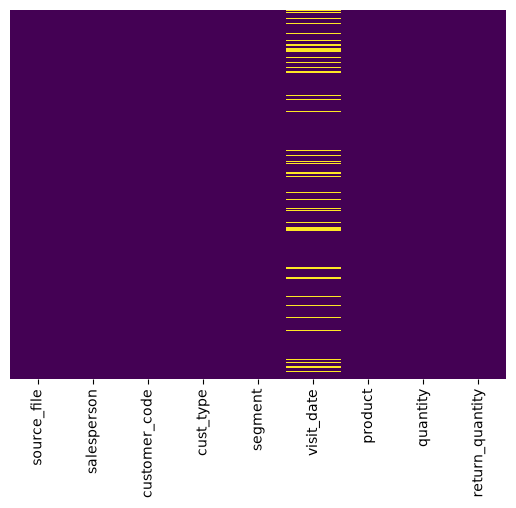

In [146]:
sns.heatmap(sales.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [147]:
sales.isnull().sum()

source_file             0
salesperson             0
customer_code           0
cust_type               0
segment                 2
visit_date         159671
product                 0
quantity                0
return_quantity         0
dtype: int64

### a)Fix visit_date Missing Data and datatype

In [148]:
sales["visit_date"] = pandas.to_datetime(sales["visit_date"], format="%Y-%m-%d", errors="coerce")

In [149]:
sales.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

In [150]:
sales["visit_date"].isnull().sum()

np.int64(159671)

In [151]:
sales["visit_date"].dtype

dtype('<M8[us]')

In [152]:
sales.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

Mean visit date:   2025-11-19
Median visit date: 2025-11-24
Mode visit date:   2025-12-24  (4854 rows on that day)


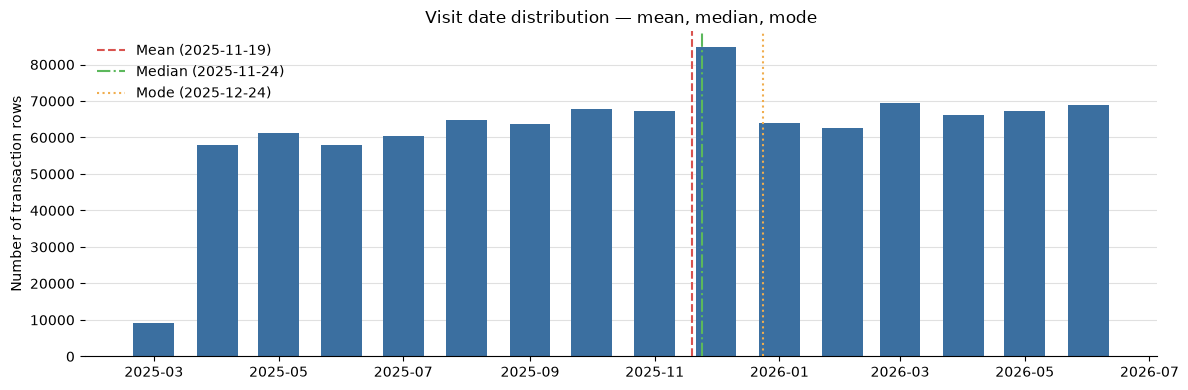

In [153]:
# --- compute the three statistics ---
mean_date = sales["visit_date"].mean()
median_date = sales["visit_date"].median()
mode_date = sales["visit_date"].mode()[0]  # busiest single day; [0] handles ties

print(f"Mean visit date:   {mean_date.date()}")
print(f"Median visit date: {median_date.date()}")
print(f"Mode visit date:   {mode_date.date()}  ({(sales['visit_date'] == mode_date).sum()} rows on that day)")

# --- plot: monthly distribution with mean/median/mode marked ---
import matplotlib.pyplot as plt

monthly_counts = sales["visit_date"].dt.to_period("M").value_counts().sort_index()
monthly_counts.index = monthly_counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_counts.index, monthly_counts.values, width=20, color="#3B6FA0", zorder=2)

ax.axvline(mean_date, color="#D9534F", linestyle="--", linewidth=1.5, zorder=3, label=f"Mean ({mean_date.date()})")
ax.axvline(median_date, color="#5CB85C", linestyle="-.", linewidth=1.5, zorder=3, label=f"Median ({median_date.date()})")
ax.axvline(mode_date, color="#F0AD4E", linestyle=":", linewidth=1.5, zorder=3, label=f"Mode ({mode_date.date()})")

ax.set_title("Visit date distribution — mean, median, mode")
ax.set_ylabel("Number of transaction rows")
ax.grid(axis="y", color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()



In [154]:
col = "visit_date"  

null_mask = sales[col].isna()
sales.loc[null_mask]


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2497,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,67.00,0
2498,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,16.36,0
2499,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Multipurpose Amber 300ml,214.00,214
2500,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,6.50,0
2501,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,111.00,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


In [155]:
missing_date_rows = sales[sales["visit_date"].isna()]
print(f"Rows with missing visit_date: {len(missing_date_rows)}")
print()

for col in [c for c in sales.columns if c != "visit_date"]:
    print(f"--- most common values of '{col}' among missing-date rows ---")
    print(missing_date_rows[col].value_counts().head(10))
    print()


Rows with missing visit_date: 159671

--- most common values of 'source_file' among missing-date rows ---
source_file
DailySalesReportNew_0105202510052025.xlsx    5885
DailySalesReportNew_1604202530042025.xlsx    5614
DailySalesReportNew_1612202531122025.xlsx    5508
DailySalesReportNew_1607202531072025.xlsx    5470
DailySalesReportNew_0104202515042025.xlsx    5429
DailySalesReportNew_1105202531062025.xlsx    5422
DailySalesReportNew_0106202515062025.xlsx    5295
DailySalesReportNew_0112202515122025.xlsx    5281
DailySalesReportNew_1608202531082025.xlsx    5267
DailySalesReportNew_0103202505032025.xlsx    5257
Name: count, dtype: int64

--- most common values of 'salesperson' among missing-date rows ---
salesperson
TONY MULEI-LANET              14623
ELISHA MARWA-TOWN B           14617
JOHN MWANGI-CBD               14048
JOSPHAT ONDIGO-PIPELINE       13683
SEBASTIAN MUKHANZI-GILGIL     13539
ERASTUS LIMO-BAHATIHESHIMA    12517
JOSEPH MWANIKI-KANU           12359
VINCENT MUSERA-OLK ROUT

### Dropping of missing Data due to finding out they are invalid rows

In [156]:
sales = sales.dropna(subset=["visit_date"])

In [157]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            2
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

### b)Fix Segment Missing Data and Imputed with the Mode

In [158]:
col2 = "segment"  

null_mask = sales[col2].isna()
sales.loc[null_mask]


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
815724,DailySalesReportNew_1606202530062025.xlsx,Marvin Odhiambo,KE0061568,Credit,NaN,2025-06-17,Liberty Potable Brown Spirit 25cl 40X01,2.0,0
815725,DailySalesReportNew_1606202530062025.xlsx,Marvin Odhiambo,KE0061568,Credit,NaN,2025-06-17,Kenya Cane Lemon & Ginger 25cl 40X01,2.0,0


In [159]:
segment_cat = sales["segment"].astype("category")
codes = segment_cat.cat.codes  # each category mapped to an integer, alphabetical order by default

print("Mode:  ", sales["segment"].mode()[0])
print("Median:", codes.median(), f"-> category: {segment_cat.cat.categories[int(codes.median())]}")

Mode:   Bar
Median: 2.0 -> category: Event


In [160]:
col = "segment"  # change to whichever column

print(f"Number of unique values: {sales[col].nunique()}")
print()

print("Unique values:")
print(sales[col].unique())
print()

print("Mode (most frequent value):")
print(sales[col].mode())
print()

print("Frequency of every unique value (mode is just the top row here):")
print(sales[col].value_counts())


Number of unique values: 12

Unique values:
<StringArray>
[             'Bar', 'Specialist Store',       'Wholesaler',
       'Restaurant',          'Lodging',            'Event',
        'Nightclub',      'Supermarket',       'Recreation',
      'Marketplace',      'Convenience',   'Not Applicable',
                nan]
Length: 13, dtype: str

Mode (most frequent value):
0    Bar
Name: segment, dtype: str

Frequency of every unique value (mode is just the top row here):
segment
Bar                 483786
Specialist Store    401325
Wholesaler           35281
Event                20115
Lodging              14638
Nightclub            13448
Restaurant            7298
Marketplace           6579
Supermarket           5353
Recreation            3624
Convenience           2132
Not Applicable          36
Name: count, dtype: int64


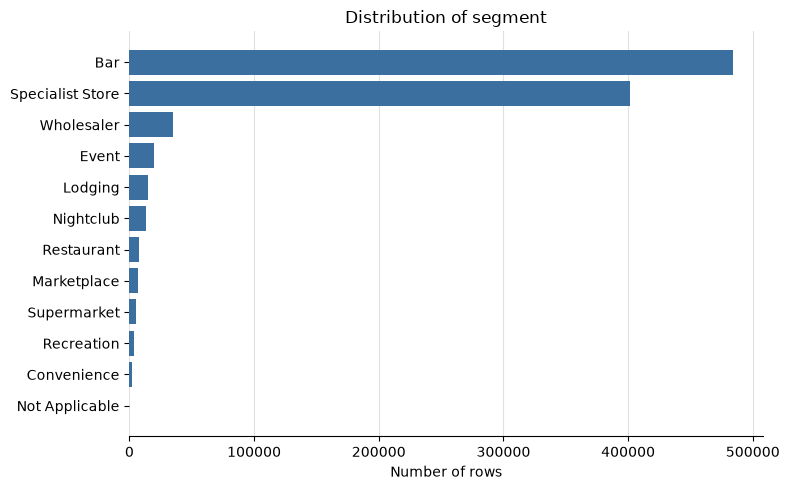

In [161]:
import matplotlib.pyplot as plt

segment_counts = sales["segment"].value_counts().sort_values(ascending=True)  # ascending so the largest bar ends up on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(segment_counts.index, segment_counts.values, color="#3B6FA0", zorder=2)

ax.set_title("Distribution of segment")
ax.set_xlabel("Number of rows")
ax.grid(axis="x", color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [162]:
sales["segment"] = sales["segment"].fillna("Bar")
sales.isna().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

# Check for unique values in the customer_code column

In [163]:
sales["customer_code"].value_counts().head(1000000)

customer_code
KE0159054    14647
KE0120507    12330
KE0134393     7317
KE0120509     6870
KE0071094     6276
             ...  
KE0142046        2
KE0062268        1
KE0062000        1
KE0062278        1
KE0171004        1
Name: count, Length: 948, dtype: int64

# Van Opening Stock Inspection


In [164]:
sales.loc[sales["customer_code"].isin(["Van opening Stock"])]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


In [165]:
sales.loc[
    (sales["customer_code"].isin(["Van opening Stock"])) &
    (sales["visit_date"].isna())
]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


#### Find the Sum of the unique value Van Opening Stock whose dates are NaT

In [166]:
(
    (sales["customer_code"].isin(["Van opening Stock"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(0)

# Van Closing Stock Inspection

In [167]:
sales.loc[sales["customer_code"].isin(["Van closing Stock"])]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


In [168]:
sales.loc[
    (sales["customer_code"].isin(["Van closing Stock"])) &
    (sales["visit_date"].isna())
]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


### Find the Sum of the unique value Van Closing Stock whose dates are NaT

In [169]:
(
    (sales["customer_code"].isin(["Van closing Stock"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(0)

## Sales Quantity Unique Value Inspection to Find the sum of visit_date which are NaT

In [170]:
(
    (sales["customer_code"].isin(["Sales Quantity"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(0)

In [171]:
(
    (sales["customer_code"].isin(["Total"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(0)

# Removing of NaT visit_date value rows since they are equally liked to the following:
### Total                46666
### Sales Quantity       42669
### Van closing Stock    41785
### Van opening Stock    34892
## Which are not actual customer codes

In [172]:
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


# Salesperson Inspection

In [173]:
sales["salesperson"].value_counts().head(1000000)

salesperson
ELISHA MARWA-TOWN B              109644
JOSPHAT ONDIGO-PIPELINE           95805
TONY MULEI-LANET                  93140
JOHN MWANGI-CBD                   91564
VINCENT MUSERA-OLK ROUTE          91258
KEY ACCOUNT                       86609
ERASTUS LIMO-BAHATIHESHIMA        83771
JOEL MAINA MWAURA-UDV VAN         73772
JOSEPH MWANIKI-KANU               72516
SEBASTIAN MUKHANZI-GILGIL         68340
ERIC KIAMA -OLK COUNTER           61552
WELDON KIRUI - NDUNDORI ROUTE     56837
Marvin Odhiambo                    3550
Vivian Jebiwott Yatich             2917
Martha  Mwende                     1190
Clare Wanyaga                       449
Barbara Mwatu                       302
Dennis Mutai                        138
Patrick Mukuna                      110
Evans Odero                          74
Norween  Kimalit                     41
Patricia Kinuthia                    26
Valentine Irungu                     12
Name: count, dtype: int64

# cust_type Inspection

In [174]:
sales["cust_type"].value_counts().head(1000000)

cust_type
Cash      902227
Credit     91390
Name: count, dtype: int64

# Segment Inspection

In [175]:
sales["segment"].value_counts().head(1000000)

segment
Bar                 483788
Specialist Store    401325
Wholesaler           35281
Event                20115
Lodging              14638
Nightclub            13448
Restaurant            7298
Marketplace           6579
Supermarket           5353
Recreation            3624
Convenience           2132
Not Applicable          36
Name: count, dtype: int64

In [176]:
sales["product"].value_counts().head(1000000)

product
Euroform Amber Local 500ml               57490
Smirldb&Guarana 330ml Can 24X01          42613
Kenya Cane Lemon & Ginger 25cl 40X01     35657
Smirnf Ice PP R 330ml CAN 24X01 local    34298
Kenya Cane Pneap 25cl 40X01              32161
                                         ...  
Complete - Mop up empties                    1
Manyatta Sweet Cider 300ml 06X04 BBIC        1
Ciroc Red Berry 70cl      06X01              1
Singleton of Dufftown 70cl 21Y 04X01         1
JW GOT SngOfIce 1L 12X01 GOT                 1
Name: count, Length: 259, dtype: int64

In [177]:
sales["quantity"].value_counts().head(1000000)

quantity
1.00     213680
2.00     111622
3.00      64897
5.00      64610
0.04      62645
          ...  
4.54          1
28.13         1
34.38         1
27.92         1
16.29         1
Name: count, Length: 1312, dtype: int64

# Will need normalization later

In [178]:
sales["quantity"].describe()

count    993617.000000
mean         13.366132
std         471.931426
min         -48.000000
25%           0.600000
50%           2.000000
75%           5.000000
max      400000.000000
Name: quantity, dtype: float64

In [179]:
print("skew:", sales["quantity"].skew())
print("rows where quantity <= 0:", (sales["quantity"] <= 0).sum())
print("99th percentile:", sales["quantity"].quantile(0.99))

skew: 650.0444634088283
rows where quantity <= 0: 99
99th percentile: 200.0


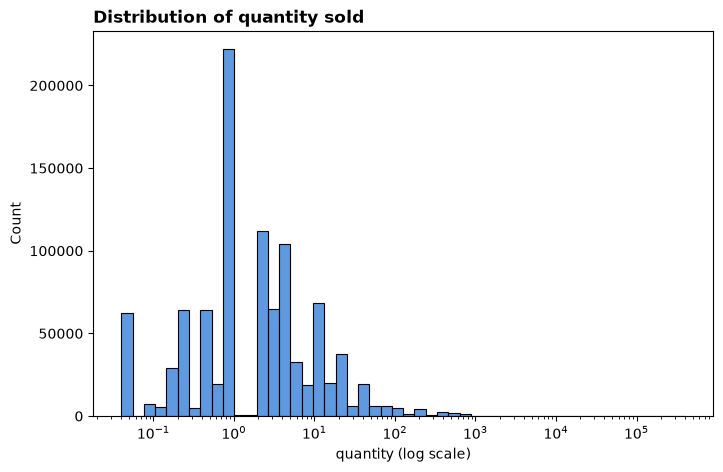

In [180]:
positive_qty = sales.loc[sales["quantity"] > 0, "quantity"]

plt.figure(figsize=(8, 5))
sns.histplot(positive_qty, bins=50, log_scale=True, color="#2a78d6")
plt.xlabel("quantity (log scale)")
plt.title("Distribution of quantity sold", loc="left", fontsize=12, fontweight="bold")
plt.show()

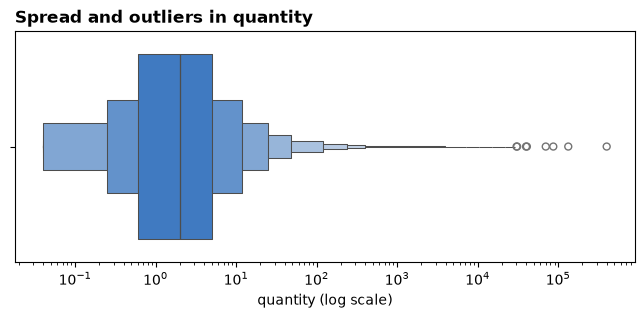

In [181]:
plt.figure(figsize=(8, 3))
sns.boxenplot(x=positive_qty, color="#2a78d6")
plt.xscale("log")
plt.xlabel("quantity (log scale)")
plt.title("Spread and outliers in quantity", loc="left", fontsize=12, fontweight="bold")
plt.show()

In [182]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

In [183]:
sales["segment"] = sales["segment"].fillna("Bar")

In [184]:
sales[sales["segment"].isnull()]


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


In [185]:
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0
